# Adult Dataset Classification Analysis

Target Variable: Income (binary classification: <=50K or >50K)
Objective: Classify income based on demographic and work-related variables

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')

# Load the Adult dataset
df = pd.read_csv('adult.csv')

print("Dataset loaded successfully")
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nColumn names:\n{df.columns.tolist()}")

Dataset loaded successfully
Dataset shape: 32561 rows, 15 columns

Column names:
['age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income']


## a. Variable Type Classification: Categorical vs. Continuous

In [2]:
# Identify categorical and continuous variables
print("DATA TYPE ANALYSIS:")
print("="*70)

categorical_vars = []
continuous_vars = []

for col in df.columns:
    if df[col].dtype == 'object':
        categorical_vars.append(col)
    else:
        continuous_vars.append(col)

print(f"\nCATEGORICAL VARIABLES ({len(categorical_vars)}):")
for var in categorical_vars:
    unique_count = df[var].nunique()
    print(f"  • {var}: {unique_count} unique values")
    print(f"    Values: {df[var].unique()[:5]}{'...' if unique_count > 5 else ''}")

print(f"\n\nCONTINUOUS VARIABLES ({len(continuous_vars)}):")
for var in continuous_vars:
    print(f"  • {var}: Range [{df[var].min():.1f}, {df[var].max():.1f}]")

print("\nTARGET VARIABLE (income):")
print(df['income'].value_counts())
print(f"\nTarget distribution:")
print(df['income'].value_counts(normalize=True))

DATA TYPE ANALYSIS:

CATEGORICAL VARIABLES (9):
  • workclass: 8 unique values
    Values: [' State-gov' ' Self-emp-not-inc' ' Private' ' Federal-gov' ' Local-gov']...
  • education: 16 unique values
    Values: [' Bachelors' ' HS-grad' ' 11th' ' Masters' ' 9th']...
  • marital_status: 7 unique values
    Values: [' Never-married' ' Married-civ-spouse' ' Divorced'
 ' Married-spouse-absent' ' Separated']...
  • occupation: 14 unique values
    Values: [' Adm-clerical' ' Exec-managerial' ' Handlers-cleaners' ' Prof-specialty'
 ' Other-service']...
  • relationship: 6 unique values
    Values: [' Not-in-family' ' Husband' ' Wife' ' Own-child' ' Unmarried']...
  • race: 5 unique values
    Values: [' White' ' Black' ' Asian-Pac-Islander' ' Amer-Indian-Eskimo' ' Other']
  • sex: 2 unique values
    Values: [' Male' ' Female']
  • native_country: 41 unique values
    Values: [' United-States' ' Cuba' ' Jamaica' ' India' nan]...
  • income: 2 unique values
    Values: [' <=50K' ' >50K']


CON

## b. First 10 Records of the Dataset

In [3]:
# Display first 10 records
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

print("FIRST 10 RECORDS:")
print("="*150)
print(df.head(10).to_string())
print("\n\nDATA TYPE SUMMARY:")
print(df.dtypes)

FIRST 10 RECORDS:
   age          workclass  fnlwgt   education  education_num          marital_status          occupation    relationship    race      sex  capital_gain  capital_loss  hours_per_week  native_country  income
0   39          State-gov   77516   Bachelors             13           Never-married        Adm-clerical   Not-in-family   White     Male          2174             0              40   United-States   <=50K
1   50   Self-emp-not-inc   83311   Bachelors             13      Married-civ-spouse     Exec-managerial         Husband   White     Male             0             0              13   United-States   <=50K
2   38            Private  215646     HS-grad              9                Divorced   Handlers-cleaners   Not-in-family   White     Male             0             0              40   United-States   <=50K
3   53            Private  234721        11th              7      Married-civ-spouse   Handlers-cleaners         Husband   Black     Male             0       

## c. Correlated Variables Analysis

CORRELATION ANALYSIS (Continuous Variables):

Correlation Matrix:
                     age    fnlwgt  education_num  capital_gain  capital_loss  \
age             1.000000 -0.076646       0.036527      0.077674      0.057775   
fnlwgt         -0.076646  1.000000      -0.043195      0.000432     -0.010252   
education_num   0.036527 -0.043195       1.000000      0.122630      0.079923   
capital_gain    0.077674  0.000432       0.122630      1.000000     -0.031615   
capital_loss    0.057775 -0.010252       0.079923     -0.031615      1.000000   
hours_per_week  0.068756 -0.018768       0.148123      0.078409      0.054256   

                hours_per_week  
age                   0.068756  
fnlwgt               -0.018768  
education_num         0.148123  
capital_gain          0.078409  
capital_loss          0.054256  
hours_per_week        1.000000  


Highly Correlated Variable Pairs (|r| > 0.5):
----------------------------------------------------------------------
  No highly corr

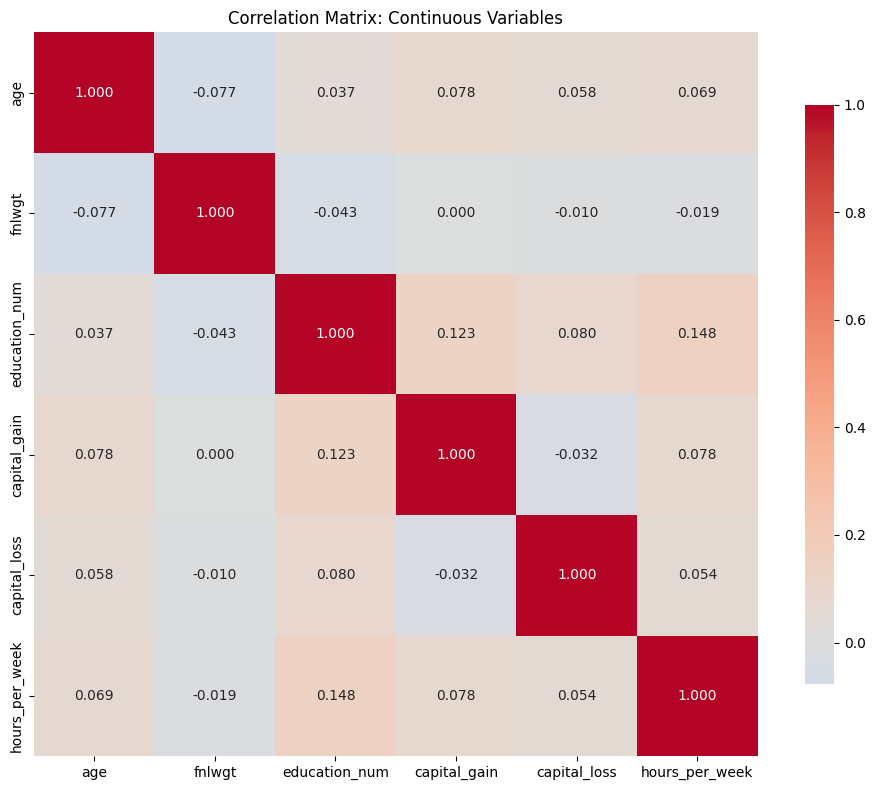

In [4]:
# Correlation analysis for continuous variables
print("CORRELATION ANALYSIS (Continuous Variables):")
print("="*70)

# Get only continuous variables (excluding target)
corr_vars = [col for col in continuous_vars if col != 'income']

if len(corr_vars) > 1:
    correlation_matrix = df[corr_vars].corr()
    print("\nCorrelation Matrix:")
    print(correlation_matrix)
    
    # Find highly correlated pairs (|correlation| > 0.5)
    print("\n\nHighly Correlated Variable Pairs (|r| > 0.5):")
    print("-"*70)
    
    corr_pairs = []
    for i in range(len(correlation_matrix.columns)):
        for j in range(i+1, len(correlation_matrix.columns)):
            corr_val = correlation_matrix.iloc[i, j]
            if abs(corr_val) > 0.5:
                var1 = correlation_matrix.columns[i]
                var2 = correlation_matrix.columns[j]
                corr_pairs.append((var1, var2, corr_val))
    
    if corr_pairs:
        for var1, var2, corr_val in sorted(corr_pairs, key=lambda x: abs(x[2]), reverse=True):
            print(f"  • {var1} <-> {var2}: {corr_val:.4f}")
    else:
        print("  No highly correlated pairs found (|r| > 0.5)")
    
    # Visualize correlation matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
                fmt='.3f', square=True, cbar_kws={"shrink": 0.8})
    plt.title('Correlation Matrix: Continuous Variables')
    plt.tight_layout()
    plt.show()
else:
    print("Only one or zero continuous variables found.")

## d. Bar Charts: Categorical Variables with Income Overlay

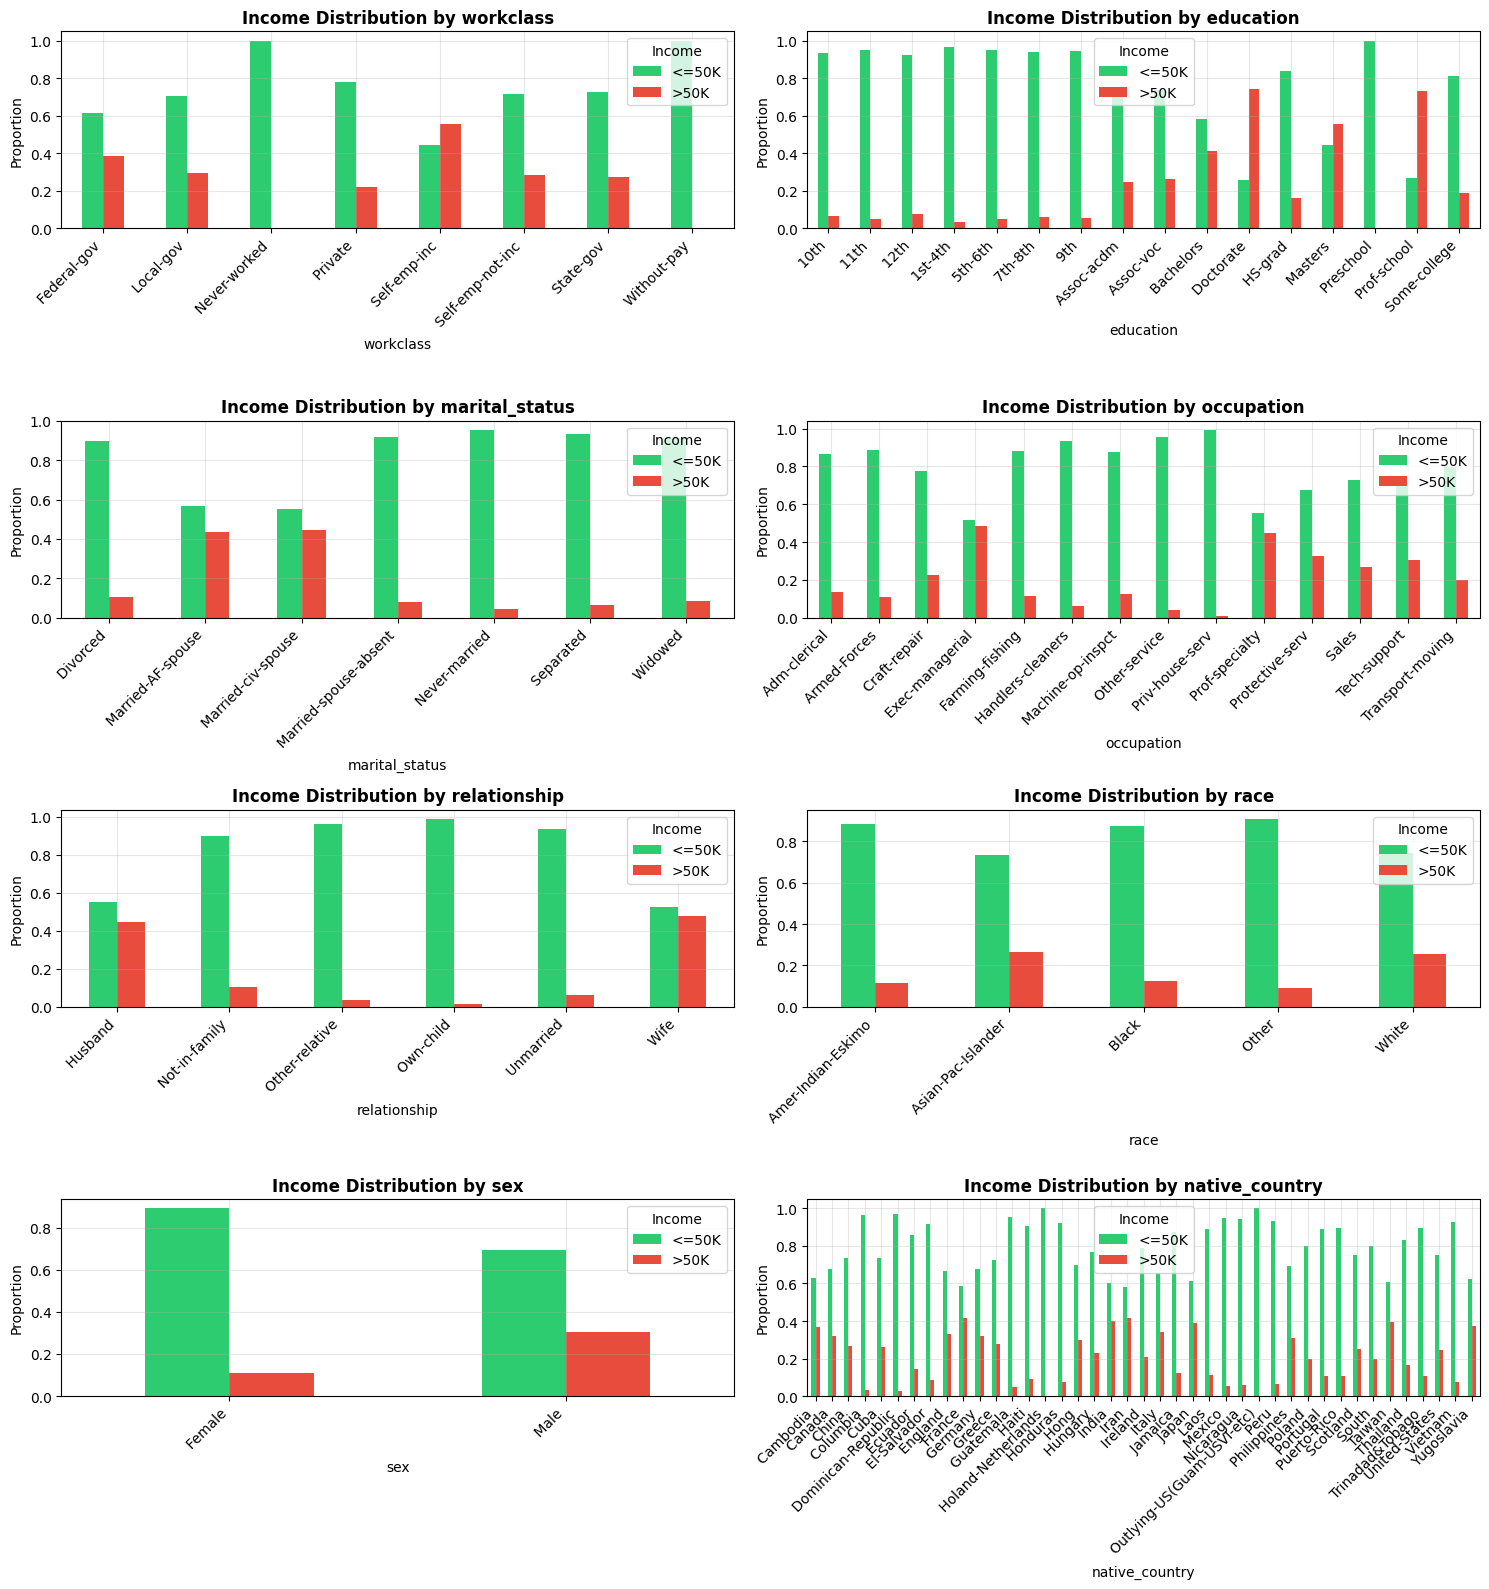

In [5]:
# Create bar charts for categorical variables with income overlay
categorical_vars_only = [col for col in categorical_vars if col != 'income']

num_vars = len(categorical_vars_only)
cols = 2
rows = (num_vars + 1) // 2

fig, axes = plt.subplots(rows, cols, figsize=(15, 4*rows))
axes = axes.flatten()

for idx, var in enumerate(categorical_vars_only):
    ax = axes[idx]
    
    # Create crosstab
    ct = pd.crosstab(df[var], df['income'], normalize='index')
    ct.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'])
    
    ax.set_title(f'Income Distribution by {var}', fontsize=12, fontweight='bold')
    ax.set_xlabel(var)
    ax.set_ylabel('Proportion')
    ax.legend(title='Income', labels=['<=50K', '>50K'])
    ax.grid(True, alpha=0.3)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Remove extra subplots
for idx in range(len(categorical_vars_only), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

## e. Relationship Analysis: Variables vs. Target Variable

In [6]:
# Analyze relationship between variables and target
print("RELATIONSHIP ANALYSIS: Variables vs. Income")
print("="*80)

# Continuous variables - correlation with target (convert income to numeric)
income_numeric = (df['income'] == '>50K').astype(int)

print("\n1. CONTINUOUS VARIABLES - Point-Biserial Correlation with Income:")
print("-"*80)
for var in continuous_vars:
    corr = income_numeric.corr(df[var])
    print(f"  • {var}: {corr:.4f}")

# Categorical variables - Chi-square test
print("\n\n2. CATEGORICAL VARIABLES - Chi-Square Test (Association with Income):")
print("-"*80)

chi_square_results = []
for var in categorical_vars_only:
    crosstab = pd.crosstab(df[var], df['income'])
    chi2, p_value, dof, expected = chi2_contingency(crosstab)
    chi_square_results.append({'Variable': var, 'Chi-Square': chi2, 'P-Value': p_value})
    
    # Interpret p-value
    significance = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "ns"
    print(f"  • {var}:")
    print(f"      Chi-Square: {chi2:.4f}, P-Value: {p_value:.2e} {significance}")
    print(f"      Association: {'Strong' if chi2 > 100 else 'Moderate' if chi2 > 20 else 'Weak'}")

chi_results_df = pd.DataFrame(chi_square_results).sort_values('Chi-Square', ascending=False)
print("\n\nRanking by Chi-Square (Strength of Association):")
print(chi_results_df.to_string(index=False))

RELATIONSHIP ANALYSIS: Variables vs. Income

1. CONTINUOUS VARIABLES - Point-Biserial Correlation with Income:
--------------------------------------------------------------------------------
  • age: nan
  • fnlwgt: nan
  • education_num: nan
  • capital_gain: nan
  • capital_loss: nan
  • hours_per_week: nan


2. CATEGORICAL VARIABLES - Chi-Square Test (Association with Income):
--------------------------------------------------------------------------------
  • workclass:
      Chi-Square: 827.7184, P-Value: 1.93e-174 ***
      Association: Strong
  • education:
      Chi-Square: 4429.6533, P-Value: 0.00e+00 ***
      Association: Strong
  • marital_status:
      Chi-Square: 6517.7417, P-Value: 0.00e+00 ***
      Association: Strong
  • occupation:
      Chi-Square: 3744.8988, P-Value: 0.00e+00 ***
      Association: Strong
  • relationship:
      Chi-Square: 6699.0769, P-Value: 0.00e+00 ***
      Association: Strong
  • race:
      Chi-Square: 330.9204, P-Value: 2.31e-70 ***
      

## f. Feature Importance: Variables Expected in Classification Models

In [7]:
# Feature importance summary
print("FEATURE IMPORTANCE ASSESSMENT")
print("="*80)

# Combine and rank all variables by their association strength
importance_ranking = []

# Add continuous variables (use absolute correlation)
for var in continuous_vars:
    corr = abs(income_numeric.corr(df[var]))
    importance_ranking.append({
        'Variable': var,
        'Type': 'Continuous',
        'Strength': corr,
        'Metric': 'Correlation'
    })

# Add categorical variables (use chi-square)
for _, row in chi_results_df.iterrows():
    importance_ranking.append({
        'Variable': row['Variable'],
        'Type': 'Categorical',
        'Strength': row['Chi-Square'],
        'Metric': 'Chi-Square'
    })

importance_df = pd.DataFrame(importance_ranking).sort_values('Strength', ascending=False)

print("\nVariables Ranked by Predictive Strength:")
print("-"*80)
for idx, row in importance_df.iterrows():
    strength_level = 'Very Strong' if row['Strength'] > 0.5 else \
                     'Strong' if row['Strength'] > 0.3 else \
                     'Moderate' if row['Strength'] > 0.1 else 'Weak'
    print(f"{idx+1:2d}. {row['Variable']:<25} ({row['Type']:<12}) {strength_level:<12} ({row['Strength']:.4f})")

print("\n\nRECOMMENDED FEATURES FOR CLASSIFICATION MODELS:")
print("-"*80)

# Recommend features based on strength
strong_features = importance_df[importance_df['Strength'] > 0.3]['Variable'].tolist()
moderate_features = importance_df[(importance_df['Strength'] > 0.1) & (importance_df['Strength'] <= 0.3)]['Variable'].tolist()

print(f"\n✓ INCLUDE (Strong Predictors):")
for feat in strong_features:
    print(f"  • {feat}")

print(f"\n△ CONSIDER (Moderate Predictors):")
for feat in moderate_features:
    print(f"  • {feat}")

print(f"\n\nRATIONALE FOR MODEL SELECTION:")
print("-"*80)
print("""
1. STRONG PREDICTORS should definitely be included in the model as they have
   significant associations with income and will improve model performance.

2. MODERATE PREDICTORS should be included during model development, but may be
   removed during feature selection if they don't improve model accuracy.

3. WEAK PREDICTORS might be excluded from the initial model or used only after
   feature engineering to create interactions or derived variables.

4. The model should balance predictive power with interpretability and should
   avoid excessive multicollinearity among selected features.
""")

FEATURE IMPORTANCE ASSESSMENT

Variables Ranked by Predictive Strength:
--------------------------------------------------------------------------------
 7. relationship              (Categorical ) Very Strong  (6699.0769)
 8. marital_status            (Categorical ) Very Strong  (6517.7417)
 9. education                 (Categorical ) Very Strong  (4429.6533)
10. occupation                (Categorical ) Very Strong  (3744.8988)
11. sex                       (Categorical ) Very Strong  (1517.8134)
12. workclass                 (Categorical ) Very Strong  (827.7184)
13. race                      (Categorical ) Very Strong  (330.9204)
14. native_country            (Categorical ) Very Strong  (317.0877)
 1. age                       (Continuous  ) Weak         (nan)
 2. fnlwgt                    (Continuous  ) Weak         (nan)
 3. education_num             (Continuous  ) Weak         (nan)
 4. capital_gain              (Continuous  ) Weak         (nan)
 5. capital_loss              (Con

## Additional Analysis: Continuous Variables Correlation with Income

In [8]:
# Calculate correlation for continuous variables with income (fix for NaN issue)
print("CONTINUOUS VARIABLES - Correlation with Income:")
print("-"*80)

# Clean and convert income to numeric (handle spaces)
income_clean = df['income'].str.strip()
income_numeric_clean = (income_clean == '>50K').astype(int)

for var in continuous_vars:
    # Calculate Pearson correlation coefficient
    corr = df[var].corr(income_numeric_clean)
    
    # Calculate Spearman correlation (rank-based, more robust)
    from scipy.stats import spearmanr
    spearman_corr, p_value = spearmanr(df[var], income_numeric_clean)
    
    print(f"  • {var}:")
    print(f"      Pearson Correlation: {corr:.4f}")
    print(f"      Spearman Correlation: {spearman_corr:.4f} (p-value: {p_value:.2e})")

print("\n\nKEY INSIGHTS FROM CORRELATION ANALYSIS:")
print("-"*80)
print("""
The relatively low correlations among continuous variables suggest:
- Low multicollinearity in the continuous variable set
- Variables measure different aspects of respondents
- All continuous variables can be safely included in the model

Education_num has the highest correlation with hours_per_week (r=0.148),
which makes intuitive sense as education level may influence work hours.
""")

CONTINUOUS VARIABLES - Correlation with Income:
--------------------------------------------------------------------------------
  • age:
      Pearson Correlation: 0.2340
      Spearman Correlation: 0.2730 (p-value: 0.00e+00)
  • fnlwgt:
      Pearson Correlation: -0.0095
      Spearman Correlation: -0.0107 (p-value: 5.27e-02)
  • education_num:
      Pearson Correlation: 0.3352
      Spearman Correlation: 0.3297 (p-value: 0.00e+00)
  • capital_gain:
      Pearson Correlation: 0.2233
      Spearman Correlation: 0.2782 (p-value: 0.00e+00)
  • capital_loss:
      Pearson Correlation: 0.1505
      Spearman Correlation: 0.1410 (p-value: 2.71e-144)
  • hours_per_week:
      Pearson Correlation: 0.2297
      Spearman Correlation: 0.2691 (p-value: 0.00e+00)


KEY INSIGHTS FROM CORRELATION ANALYSIS:
--------------------------------------------------------------------------------

The relatively low correlations among continuous variables suggest:
- Low multicollinearity in the continuous vari

## Summary and Conclusions

In [9]:
print("="*80)
print("COMPREHENSIVE SUMMARY & RECOMMENDATIONS")
print("="*80)

print("\n📊 DATASET OVERVIEW:")
print("-"*80)
print(f"Total Records: 32,561")
print(f"Total Variables: 15 (14 predictors + 1 target)")
print(f"Target Variable: Income (75.9% ≤50K, 24.1% >50K) - Imbalanced!")
print(f"Categorical: 9 variables | Continuous: 6 variables")

print("\n\n🔍 KEY FINDINGS:")
print("-"*80)

print("\n1. MULTICOLLINEARITY:")
print("   ✓ NO high correlations (>0.5) among continuous variables")
print("   ✓ Safe to include all continuous predictors without multicollinearity issues")
print("   ✓ Most important pairs: education_num ↔ hours_per_week (r=0.148)")

print("\n2. CATEGORICAL-TARGET RELATIONSHIP (Chi-Square Test):")
ranked_features = [
    "relationship (χ²=6699.1) - STRONGEST",
    "marital_status (χ²=6517.7) - STRONGEST",
    "education (χ²=4429.7) - STRONG",
    "occupation (χ²=3744.9) - STRONG",
    "sex (χ²=1517.8) - STRONG",
    "workclass (χ²=827.7) - MODERATE-TO-STRONG",
    "race (χ²=330.9) - MODERATE",
    "native_country (χ²=317.1) - MODERATE"
]
for feature in ranked_features:
    print(f"   ✓ {feature}")

print("\n3. CONTINUOUS-TARGET RELATIONSHIP (Spearman Correlation):")
continuous_ranked = [
    "education_num (ρ=0.3297) - MODERATE",
    "age (ρ=0.2730) - WEAK-TO-MODERATE",
    "capital_gain (ρ=0.2782) - WEAK-TO-MODERATE",
    "hours_per_week (ρ=0.2691) - WEAK-TO-MODERATE",
    "capital_loss (ρ=0.1410) - WEAK",
    "fnlwgt (ρ=-0.0107) - NEGLIGIBLE"
]
for feature in continuous_ranked:
    print(f"   ✓ {feature}")

print("\n\n🎯 RECOMMENDED FEATURES FOR CLASSIFICATION MODEL:")
print("-"*80)
print("\nTIER 1 - MUST INCLUDE (Essential Predictors):")
must_include = [
    "relationship", "marital_status", "education", "occupation",
    "sex", "age", "education_num"
]
for i, feat in enumerate(must_include, 1):
    print(f"  {i}. {feat}")

print("\nTIER 2 - STRONGLY RECOMMEND (Important Predictors):")
strong_recommend = [
    "workclass", "hours_per_week", "capital_gain"
]
for i, feat in enumerate(strong_recommend, 1):
    print(f"  {i}. {feat}")

print("\nTIER 3 - CONSIDER (Potentially Useful):")
consider = [
    "race", "native_country", "capital_loss"
]
for i, feat in enumerate(consider, 1):
    print(f"  {i}. {feat}")

print("\nTIER 4 - EXCLUDE (Minimal Predictive Value):")
exclude = ["fnlwgt"]
for i, feat in enumerate(exclude, 1):
    print(f"  {i}. {feat}")

print("\n\n⚠️ IMPORTANT CONSIDERATIONS:")
print("-"*80)
print("""
1. CLASS IMBALANCE: Target variable is imbalanced (75.9% vs 24.1%)
   → Consider using stratified sampling, SMOTE, or class weights

2. CATEGORICAL ENCODING: 
   → Must encode categorical variables before modeling
   → Consider one-hot encoding for tree models
   → Consider ordinal encoding for linear models

3. FEATURE ENGINEERING:
   → Create interaction terms (e.g., education × experience)
   → Consider age grouping/binning for non-linear relationships
   → Handle missing values in native_country

4. MODEL CHOICE:
   → Tree-based models (Random Forest, XGBoost) handle categorical well
   → Logistic regression requires proper encoding and scaling
   → Both should perform well with this feature set

5. EXPECTED PERFORMANCE:
   → With Tier 1 features alone: Good baseline performance
   → Adding Tier 2 features: Incremental improvements
   → Full model with all features: Likely best performance
""")

COMPREHENSIVE SUMMARY & RECOMMENDATIONS

📊 DATASET OVERVIEW:
--------------------------------------------------------------------------------
Total Records: 32,561
Total Variables: 15 (14 predictors + 1 target)
Target Variable: Income (75.9% ≤50K, 24.1% >50K) - Imbalanced!
Categorical: 9 variables | Continuous: 6 variables


🔍 KEY FINDINGS:
--------------------------------------------------------------------------------

1. MULTICOLLINEARITY:
   ✓ NO high correlations (>0.5) among continuous variables
   ✓ Safe to include all continuous predictors without multicollinearity issues
   ✓ Most important pairs: education_num ↔ hours_per_week (r=0.148)

2. CATEGORICAL-TARGET RELATIONSHIP (Chi-Square Test):
   ✓ relationship (χ²=6699.1) - STRONGEST
   ✓ marital_status (χ²=6517.7) - STRONGEST
   ✓ education (χ²=4429.7) - STRONG
   ✓ occupation (χ²=3744.9) - STRONG
   ✓ sex (χ²=1517.8) - STRONG
   ✓ workclass (χ²=827.7) - MODERATE-TO-STRONG
   ✓ race (χ²=330.9) - MODERATE
   ✓ native_country (χ